In [ ]:
# -*- coding: utf-8 -*-
"""mini_dataset_200"""

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas openpyxl

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/My Drive/DATASET_TESIS_CIC/CLASIFICACIÓN/mini_dataset_100.csv', encoding='latin-1', quotechar='"', on_bad_lines='skip', dtype={'id': str})

In [ ]:
print(df.columns)

Index(['id', 'text', 'createdAt', 'author_location', 'author_createdAt',
       'place_full_name', 'place_name', 'text_cleaned', 'lon', 'lat',
       'Sentiment_PySentimiento', 'category'],
      dtype='object')


In [ ]:
# Eliminar filas con valores nulos en 'text_cleaned' o 'category'
df = df.dropna(subset=['text_cleaned', 'category'])

df['category'] = df['category'].str.strip().str.lower().str.replace("not_ciberbullying", "not_ciberbullying")


# Cargar el tokenizer y modelo de BETO
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
model = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

# Función para obtener embeddings
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:,0,:].squeeze().numpy()

# Obtener embeddings para todos los textos
embeddings = np.array([get_embedding(text) for text in df['text_cleaned']])

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(embeddings, df['category'], test_size=0.2, random_state=42)

# Entrenar el modelo
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predecir y evaluar
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

                   precision    recall  f1-score   support

         denuncia       0.50      0.33      0.40         3
            etnia       0.00      0.00      0.00         2
           género       0.00      0.00      0.00         2
not_ciberbullying       0.81      0.94      0.87        31
        otro_tipo       0.00      0.00      0.00         1
         político       1.00      0.50      0.67         2

         accuracy                           0.76        41
        macro avg       0.38      0.29      0.32        41
     weighted avg       0.69      0.76      0.72        41



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


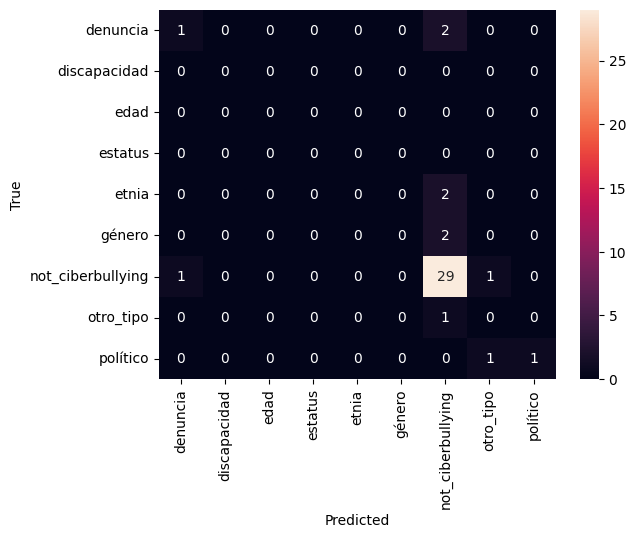

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()